🚀 開始執行 COVID-19 平行宇宙測試...

正在模擬: Universe A: 歷史現實 Historical Reality ...
正在模擬: Universe B: 中國不封城 CN No Lockdown ...
正在模擬: Universe C: 美供應鏈強韌 US Resilient Supply ...

✅ 模擬完成！


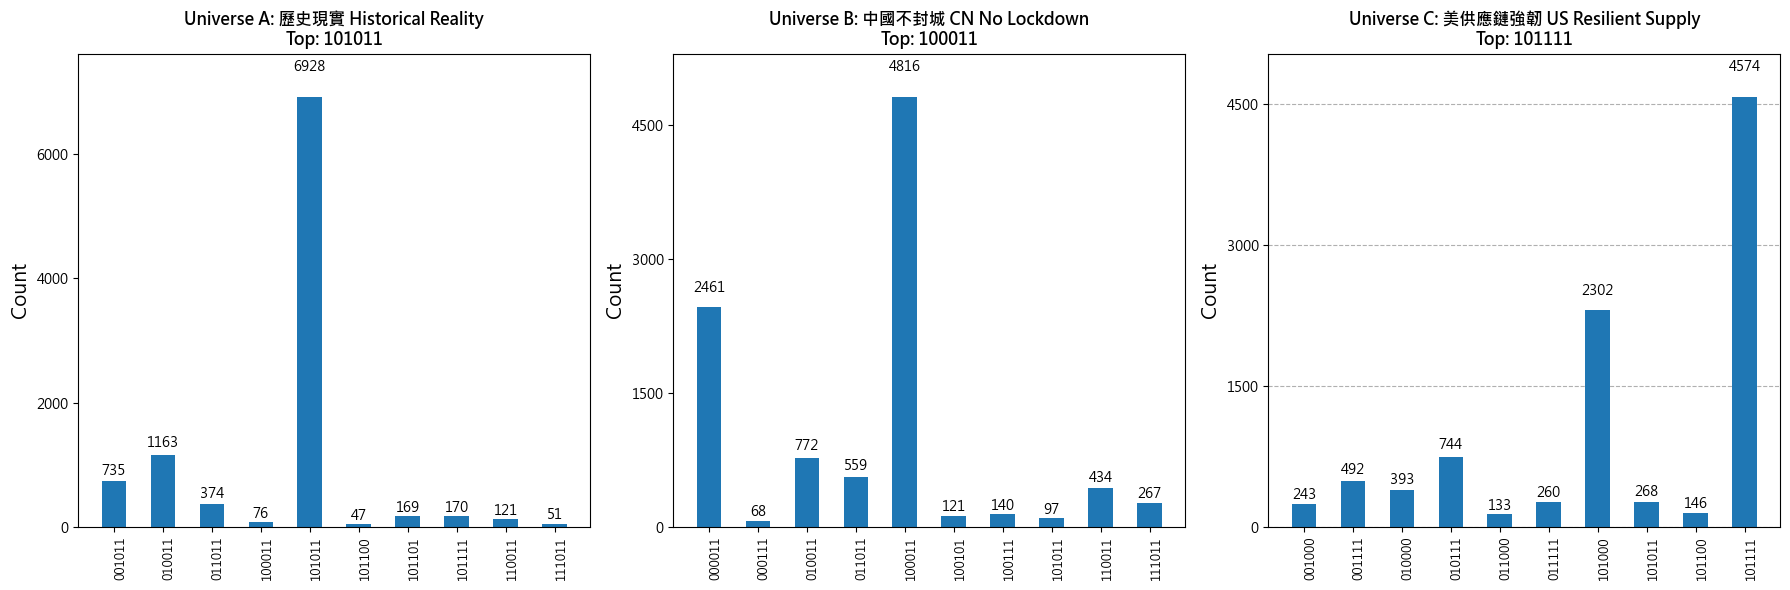


📊 === 敏感度分析報告 ===
[Universe A: 歷史現實 Historical Reality] -> 顯化結果: 101011 (機率 69.3%)
   -> 吻合歷史現實 (驗證通過)
[Universe B: 中國不封城 CN No Lockdown] -> 顯化結果: 100011 (機率 48.2%)
   -> 卦象發生偏移 (敏感度測試通過)
[Universe C: 美供應鏈強韌 US Resilient Supply] -> 顯化結果: 101111 (機率 45.7%)
   -> 卦象發生偏移 (敏感度測試通過)


In [3]:
"""
================================================================================
【Project IQD：COVID-19 平行宇宙敏感度推演 量子因果引擎】
================================================================================
[1. 核心映射表 (Mapping Table)]
▶ Qubits (觀測維度): 嚴格切分為中美雙鏈 (6 Qubits)
  [美國 US Chain] 
  - q0: 國家政策 (Nation)
  - q1: 企業動能 (Corp)
  - q2: 底層供應鏈 (Supply)
  [中國 CN Chain]
  - q3: 國家政策 (Nation)
  - q4: 企業動能 (Corp)
  - q5: 底層供應鏈 (Supply)

▶ Gates (邏輯閘與事件物理意義):
  - Ry 閘 (Y-Rotation): 政策變數注入。將推演的經濟觀測值(-1.0 ~ 1.0)轉換為張力角度。
  - CNOT 閘 (CX): 垂直因果傳導。模擬國家政策(控制端)強制牽動企業與供應鏈(目標端)。
  - CZ 閘 (Phase Control): 水平地緣死鎖。中美大國(q0與q3)互不相讓的對稱物理死鎖。

▶ 測量輸出 (Bitstring -> 卦象顯化):
  - 101011 (Universe A): 火澤睽卦 (歷史現實死局，中美心思背離、互相猜忌)
  - 100011 (Universe B): 山澤損卦 (中國不封城，解除絕對死鎖，承受局部減損以換取全局生機)
  - 101111 (Universe C): 火天大有卦 (美供應鏈強韌，底層支撐頂層運作，逆勢創造豐盛動能)

[2. 最小案例流程圖 (Minimal Case Flow) - 決定論的反事實推演]
設定 3 種平行宇宙張力值 ──> [數值映射] 將變數 (-1.0~1.0) 轉為量子旋轉角度 
                      ──> [張力注入] 對 q0~q5 施加 Ry 閘 (神之手介入：微調特定節點壓力) 
                      ──> [垂直糾纏] 施加 CNOT 閘，維持僵硬的內部因果結構不變
                      ──> [水平死鎖] 施加 CZ 閘，維持僵硬的中美對撞結構不變
                      ──> [最終測量] 波函數顯化 (Collapse) 
                      ──> [敏感度分析] 10000 次射擊後，觀察微小變數是否能「降低絕對顯化機率」
================================================================================
"""

# ==========================================================
# 實驗：COVID-19 平行宇宙敏感度測試
# ==========================================================
import matplotlib.pyplot as plt

# --- [新增] 修復 Matplotlib 中文顯示 (豆腐塊) 問題 ---
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang TC', 'Arial Unicode MS'] # 依序支援 Win, Mac
plt.rcParams['axes.unicode_minus'] = False # 確保負號不會變成方塊
# ------------------------------------------------------

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

# ==========================================================
# 1. 定義三個平行宇宙的參數 (主動介入的推演變數)
# ==========================================================
# 數值定義: -1.0 (極度收縮/封控/斷鏈) 到 +1.0 (強勢擴張/強韌)
scenarios = [
    {
        "name": "Universe A: 歷史現實 Historical Reality",
        "desc": "CN Lockdown (-), US Broken Supply (-)",
        "nodes": {
            "US_Nation": -0.9, "US_Corp": 0.8,  "US_Supply": -0.8, # 美國：實體斷鏈但數位暴漲
            "CN_Nation": -0.5, "CN_Corp": -0.7, "CN_Supply": -0.6  # 中國：歷史現實的全面封控
        }
    },
    {
        "name": "Universe B: 中國不封城 CN No Lockdown",
        "desc": "CN Economy Active (+), US Broken Supply (-)",
        "nodes": {
            "US_Nation": -0.9, "US_Corp": 0.8,  "US_Supply": -0.8,
            # 🟢 修改點 (神之手)：假設中國維持經濟運轉，大幅調降張力角度
            "CN_Nation": 0.6,  "CN_Corp": 0.5,  "CN_Supply": -0.2
        }
    },
    {
        "name": "Universe C: 美供應鏈強韌 US Resilient Supply",
        "desc": "CN Lockdown (-), US Supply Strong (+)",
        "nodes": {
            # 🟢 修改點 (神之手)：假設美國供應鏈極度強韌沒有斷裂
            "US_Nation": -0.2, "US_Corp": 0.9,  "US_Supply": 0.7,
            "CN_Nation": -0.5, "CN_Corp": -0.7, "CN_Supply": -0.6
        }
    }
]

# ==========================================================
# 2. 沿用之前的建構函數 (保持模型因果邏輯一致)
# ==========================================================
def value_to_angle(val):
    """將經濟變數映射為量子偏轉角度：-1 (風險極大化) -> +1 (平穩)"""
    return (1 - val) * (np.pi / 2)

def build_circuit(data_node):
    qc = QuantumCircuit(6)
    
    # --- A. 張力注入 (Encoding) ---
    # 使用 Ry 閘接收政策變數，轉化為物理振幅
    qc.ry(value_to_angle(data_node["US_Nation"]), 0)
    qc.ry(value_to_angle(data_node["US_Corp"]), 1)
    qc.ry(value_to_angle(data_node["US_Supply"]), 2)
    qc.ry(value_to_angle(data_node["CN_Nation"]), 3)
    qc.ry(value_to_angle(data_node["CN_Corp"]), 4)
    qc.ry(value_to_angle(data_node["CN_Supply"]), 5)
    
    # --- B. 垂直糾纏 (Vertical Entanglement) ---
    qc.cx(0, 1) # 國家政策強制牽動企業
    qc.cx(1, 2) # 企業強制牽動供應鏈
    qc.cx(3, 4)
    qc.cx(4, 5)
    
    # --- C. 水平死鎖 (Horizontal Tension) ---
    qc.cz(0, 3) # 中美互斥對撞的極度剛硬結構
    
    # --- D. 觀測顯化 ---
    qc.measure_all()
    return qc

# ==========================================================
# 3. 執行模擬 (量子敏感度測試)
# ==========================================================
simulator = AerSimulator()
results = []

print("🚀 開始執行 COVID-19 平行宇宙測試...\n")

for sc in scenarios:
    print(f"正在模擬: {sc['name']} ...")
    qc = build_circuit(sc["nodes"])
    compiled_circuit = transpile(qc, simulator)
    job = simulator.run(compiled_circuit, shots=10000) # 超級電腦觀測 10000 次
    counts = job.result().get_counts(qc)

    # 找出共識強度最高（機率最大）的冠軍主態卦象
    top_hex = sorted(counts.items(), key=lambda x: x[1], reverse=True)[0]
    results.append({
        "scenario": sc["name"],
        "counts": counts,
        "top_hex": top_hex
    })

print("\n✅ 模擬完成！")

# ==========================================================
# 4. 視覺化分析 (三張圖並排)
# ==========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 給 X 軸留點空間

for i, res in enumerate(results):
    # 🟢 核心修復 1：過濾量子雜訊，只取機率最高的前 10 個卦象
    top_10_counts = dict(sorted(res["counts"].items(), key=lambda item: item[1], reverse=True)[:10])
    
    # 畫出過濾後的圖表 (顯示波函數顯化時的命運收束強度)
    plot_histogram(top_10_counts, ax=axes[i])
    axes[i].set_title(f"{res['scenario']}\nTop: {res['top_hex'][0]}", fontsize=12, fontweight='bold')
    
    # 🟢 核心修復 2：將 X 軸標籤旋轉 90 度垂直顯示，並將字體縮小至 9
    axes[i].tick_params(axis='x', labelrotation=90, labelsize=9)

# 調整排版避免被切掉
plt.tight_layout()
plt.show()

# ==========================================================
# 5. 文字解讀輸出 (自動生成敏感度分析報告)
# ==========================================================
print("\n📊 === 敏感度分析報告 ===")
for res in results:
    hex_code = res['top_hex'][0]
    prob = (res['top_hex'][1] / 10000) * 100
    print(f"[{res['scenario']}] -> 顯化結果: {hex_code} (機率 {prob:.1f}%)")
    
    # 驗證歷史軌跡與量子擾動的成效
    if hex_code == "101011": # 這是之前的歷史死局結果
        print("   -> 吻合歷史現實 (驗證通過)")
    else:
        print("   -> 卦象發生偏移 (敏感度測試通過)")